## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
customer = pd.read_csv('../data/customer.csv')
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

print(f"Tổng số khách hàng: {len(customer)}")
print(f"Tổng số giao dịch: {len(df_success)}")

Tổng số khách hàng: 4314
Tổng số giao dịch: 407695


## 3. TẠO FEATURE RFM

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)
six_months_ago = now - pd.Timedelta(days=180)

first_6_months = df_success[df_success['InvoiceDate'] < six_months_ago]

In [4]:
# RFM cơ bản
rfm = first_6_months.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (now - x.max()).days,  # Recency
    'Invoice': 'nunique',                            # Frequency
    'Amount': 'sum'                                  # Monetary
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# thêm 2 feature: số sản phẩm khác nhau đã mua, giá trị trung bình mỗi đơn
rfm['Unique_Products'] = first_6_months.groupby('Customer ID')['StockCode'].nunique()
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

X = rfm
print(f"Số features: {X.shape[1]}")
X.head()

Số features: 5


,Recency,Frequency,Monetary,Unique_Products,Avg_Order_Value
Customer ID,,,,,
12346.0,283,10,230.55,7,23.0550
12349.0,206,2,1268.52,47,634.2600
12355.0,203,1,488.21,22,488.2100
12358.0,186,2,1697.93,34,848.9650
12359.0,262,4,1522.23,65,380.5575


## 4. TẠO NHÃN CHURN

In [5]:
last_6_months = df_success[df_success['InvoiceDate'] >= six_months_ago]
active_customers = set(last_6_months['Customer ID'].unique())

In [6]:
# Churn = 1 nếu 6 tháng cuối không mua lại, 0 nếu có mua lại
y = pd.Series(
    [1 if idx not in active_customers else 0 for idx in X.index],
    index=X.index,
    name='Churn'
)

churn_rate = y.mean()
print(f"Tỷ lệ churn: {churn_rate*100:.1f}%")
print(f"  - Churn (không mua lại): {(y == 1).sum()}")
print(f"  - Active (có mua lại): {(y == 0).sum()}")

Tỷ lệ churn: 29.4%
  - Churn (không mua lại): 833
  - Active (có mua lại): 1997


## 5. EDA - PHÂN TÍCH KHÁM PHÁ

In [7]:
churn_stats = X.join(y).groupby('Churn').mean()
print(churn_stats)

          Recency  Frequency     Monetary  Unique_Products  Avg_Order_Value
Churn                                                                      
0      234.260391   3.618928  1716.542703        56.256885       392.231197
1      264.427371   1.578631   610.753426        25.888355       356.758655


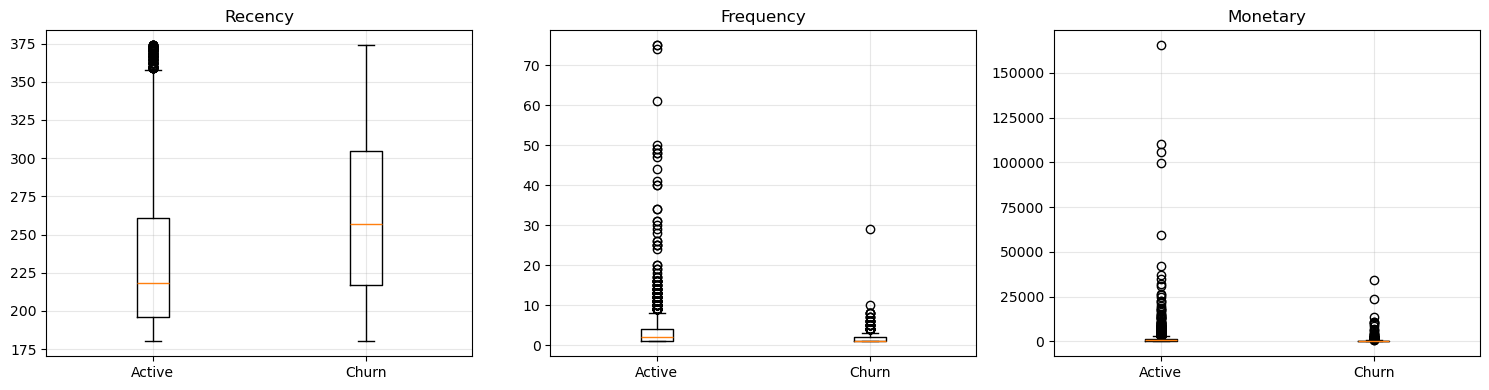

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_to_plot = ['Recency', 'Frequency', 'Monetary']

for i, feature in enumerate(features_to_plot):
    data_to_plot = [X[y == 0][feature], X[y == 1][feature]]
    axes[i].boxplot(data_to_plot, labels=['Active', 'Churn'])
    axes[i].set_title(feature)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

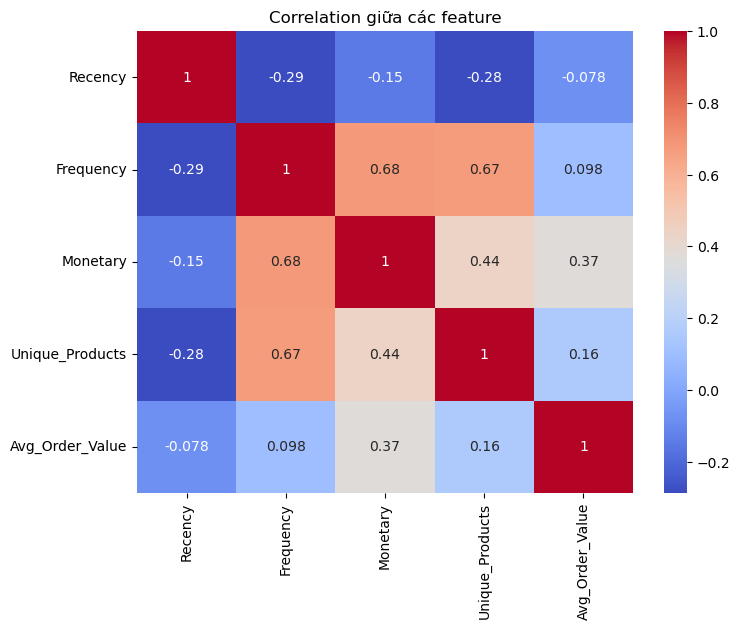

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation giữa các feature')
plt.show()

## 6. CHIA TRAIN/TEST

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Churn rate - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: 2264 | Test: 566
Churn rate - train: 0.294 | test: 0.295


## 7. TRAIN MODEL - LOGISTIC REGRESSION

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_log):.4f}")

Logistic Regression:
  Accuracy: 0.6378
  Precision: 0.4391
  Recall: 0.8204
  F1: 0.5720


## 8. TRAIN MODEL - RANDOM FOREST

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=8, class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_rf):.4f}")

Random Forest:
  Accuracy: 0.6625
  Precision: 0.4483
  Recall: 0.6228
  F1: 0.5213


## 9. SO SÁNH VÀ CHỌN MODEL

In [13]:
f1_log = f1_score(y_test, y_pred_log)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"F1 - Logistic Regression: {f1_log:.4f}")
print(f"F1 - Random Forest: {f1_rf:.4f}")

if f1_rf > f1_log:
    best_model = rf_model
    best_model_name = 'Random Forest'
    uses_scaled = False
else:
    best_model = log_model
    best_model_name = 'Logistic Regression'
    uses_scaled = True

print(f"\nModel được chọn: {best_model_name}")

F1 - Logistic Regression: 0.5720
F1 - Random Forest: 0.5213

Model được chọn: Logistic Regression


## 10. CONFUSION MATRIX

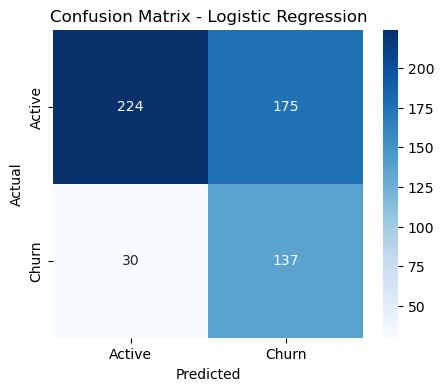

In [14]:
y_pred_best = y_pred_rf if best_model_name == 'Random Forest' else y_pred_log
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churn'], yticklabels=['Active', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 11. FEATURE IMPORTANCE

In [15]:
if best_model_name == 'Random Forest':
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(feature_importance)

    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 12. LƯU MODEL

In [16]:
import joblib

artifacts = {
    'model': best_model,
    'scaler': scaler if uses_scaled else None,
    'uses_scaled_input': uses_scaled,
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
}

joblib.dump(artifacts, '../models/churn_model.pkl')
print(f"Đã lưu model vào '../models/churn_model.pkl'")

Đã lưu model vào '../models/churn_model.pkl'


## 13. THỬ DỰ ĐOÁN CHO VÀI KHÁCH HÀNG TRONG TEST SET

In [17]:
sample_idx = X_test.sample(5, random_state=1).index
sample_customers = X_test.loc[sample_idx]

sample_input = scaler.transform(sample_customers) if uses_scaled else sample_customers
sample_pred = best_model.predict(sample_input)

sample_results = sample_customers.copy()
sample_results['Predicted_Churn'] = sample_pred
sample_results['Actual_Churn'] = y_test.loc[sample_idx]

sample_results

,Recency,Frequency,Monetary,Unique_Products,Avg_Order_Value,Predicted_Churn,Actual_Churn
Customer ID,,,,,,,
17742.0,191,5,1144.58,32,228.916,0,0
17923.0,180,1,187.50,1,187.500,1,0
15188.0,361,1,310.43,23,310.430,1,1
16654.0,248,1,269.70,14,269.700,1,0
14704.0,260,1,119.84,34,119.840,1,0


## 14. KẾT LUẬN
1. Model tốt hơn: *Logistic Regression*
2. Tỷ lệ churn thực tế: 29.4%
3. Nhận xét: model dự đoán churn dựa chủ yếu vào Recency và Frequency, khá hợp lý vì khách lâu không mua và mua ít lần thường có xu hướng rời bỏ cao hơn.
4. Hạn chế: mới chỉ thử 2 model đơn giản (Logistic Regression, Random Forest), threshold mặc định 0.5, chưa tối ưu hyperparameter. Nếu có thêm thời gian sẽ tìm hiểu thêm về GridSearch và các kỹ thuật xử lý dữ liệu mất cân bằng như SMOTE.